<a href="https://colab.research.google.com/github/saniluttu/restaurant-branch-performance-eda-day13/blob/main/Restaurant_Branch_Performance_EDA_Day13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Restaurant Branch Performance — Exploratory Data Analysis
**Day 13 Assignment**

This notebook performs an Exploratory Data Analysis (EDA) on the Restaurant Branch Performance dataset using Pandas. It covers summary statistics, descriptive analysis, distribution analysis, and correlation analysis across customers, revenue, profit, marketing spend, staff count, delivery time, and customer ratings — comparing performance across branches, regions, and store types, and concluding with key data-driven observations.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
print('Pandas version:', pd.__version__)

Pandas version: 3.0.2


## 1. Loading and Understanding the Dataset

In [ ]:
df = pd.read_csv('Day13_Restaurant_Branch_Performance_Dataset.csv')
print("Shape:", df.shape)
df.head()

Shape: (350, 22)


,Record_ID,Date,Day,Month,Branch,Region,Store_Type,Staff_Count,Marketing_Spend,Customers,Orders,Average_Bill,Revenue,Food_Cost,Operating_Cost,Profit,Avg_Delivery_Min,Customer_Rating,Temperature_C,Humidity_Percent,Weather,Promotion
0,ST0001,2026-06-06,Saturday,June,Jaipur,North,Express,7,4977.25,172,135,375.75,66766.77,27954.29,46554.90,20211.87,29.0,4.44,20.8,70.3,Clear,NaN
1,ST0002,2026-02-10,Tuesday,February,Pune,West,Premium,14,8998.30,285,263,530.64,157230.89,63816.59,96813.95,60416.94,27.9,4.56,31.3,70.7,Clear,Loyalty Offer
2,ST0003,2026-03-07,Saturday,March,Delhi,North,Premium,16,10034.97,306,264,534.97,155811.96,54874.10,89888.91,65923.05,30.2,4.36,21.4,61.5,Clear,NaN
3,ST0004,2026-05-11,Monday,May,Mumbai,West,Standard,9,5095.84,198,167,370.05,80574.05,31429.44,53531.82,27042.23,21.7,4.65,22.9,40.4,Clear,NaN
4,ST0005,2026-01-14,Wednesday,January,Kochi,South,Express,9,6681.82,148,116,364.62,56579.89,21759.51,44376.25,12203.64,26.1,4.50,29.0,44.3,Clear,Combo Deal


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Record_ID         350 non-null    str    
 1   Date              350 non-null    str    
 2   Day               350 non-null    str    
 3   Month             350 non-null    str    
 4   Branch            350 non-null    str    
 5   Region            350 non-null    str    
 6   Store_Type        350 non-null    str    
 7   Staff_Count       350 non-null    int64  
 8   Marketing_Spend   350 non-null    float64
 9   Customers         350 non-null    int64  
 10  Orders            350 non-null    int64  
 11  Average_Bill      350 non-null    float64
 12  Revenue           350 non-null    float64
 13  Food_Cost         350 non-null    float64
 14  Operating_Cost    350 non-null    float64
 15  Profit            350 non-null    float64
 16  Avg_Delivery_Min  350 non-null    float64
 17  Customer

In [ ]:
df.isna().sum()

Record_ID             0
Date                  0
Day                   0
Month                 0
Branch                0
Region                0
Store_Type            0
Staff_Count           0
Marketing_Spend       0
Customers             0
Orders                0
Average_Bill          0
Revenue               0
Food_Cost             0
Operating_Cost        0
Profit                0
Avg_Delivery_Min      0
Customer_Rating       0
Temperature_C         0
Humidity_Percent      0
Weather               0
Promotion           184
dtype: int64

In [ ]:
# Promotion has missing values — these represent days with no promotion running
df['Promotion'] = df['Promotion'].fillna('No Promotion')
df['Promotion'].value_counts()

Promotion
No Promotion     184
Weekend Offer     74
Combo Deal        59
Loyalty Offer     33
Name: count, dtype: int64

## 2. Summary Statistics

In [ ]:
df.describe()

,Staff_Count,Marketing_Spend,Customers,Orders,Average_Bill,Revenue,Food_Cost,Operating_Cost,Profit,Avg_Delivery_Min,Customer_Rating,Temperature_C,Humidity_Percent
count,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000
mean,11.957143,5516.347743,217.377143,187.054286,388.906371,86831.799657,31807.545114,56621.444486,30210.355171,26.098857,4.469314,27.740000,61.324571
std,4.338261,2050.906967,56.722524,50.558371,82.488196,36644.453901,13896.888942,18467.842215,19508.592192,4.388125,0.198258,4.903148,13.757322
min,5.000000,725.350000,77.000000,71.000000,180.000000,20540.760000,7262.010000,20782.380000,-6924.680000,13.900000,3.760000,14.500000,25.000000
25%,9.000000,4339.727500,180.250000,155.000000,337.315000,61261.717500,22326.662500,43797.670000,16915.492500,22.800000,4.320000,24.400000,51.325000
50%,11.000000,5393.370000,213.000000,182.500000,383.485000,79766.880000,28861.325000,53723.025000,26873.870000,26.100000,4.470000,27.800000,61.650000
75%,15.000000,6748.502500,255.750000,218.750000,441.765000,102976.185000,38370.370000,63961.227500,39823.742500,29.075000,4.600000,31.000000,70.375000
max,24.000000,11784.960000,360.000000,334.000000,623.280000,194018.920000,75946.590000,111489.140000,89096.190000,38.300000,4.960000,43.500000,95.000000


In [ ]:
# Categorical breakdown
for col in ['Branch', 'Region', 'Store_Type', 'Weather', 'Promotion']:
    print(f"\n{col}:")
    print(df[col].value_counts())


Branch:
Branch
Srinagar     52
Jaipur       48
Kochi        48
Bengaluru    46
Mumbai       44
Hyderabad    43
Pune         37
Delhi        32
Name: count, dtype: int64

Region:
Region
South    137
North    132
West      81
Name: count, dtype: int64

Store_Type:
Store_Type
Standard    196
Express     102
Premium      52
Name: count, dtype: int64

Weather:
Weather
Clear     189
Cloudy     82
Rain       48
Hot        31
Name: count, dtype: int64

Promotion:
Promotion
No Promotion     184
Weekend Offer     74
Combo Deal        59
Loyalty Offer     33
Name: count, dtype: int64


## 3. Descriptive Analysis — Branch, Region, and Store Type

In [ ]:
branch_summary = df.groupby('Branch').agg(
    Total_Revenue=('Revenue', 'sum'),
    Avg_Revenue=('Revenue', 'mean'),
    Total_Profit=('Profit', 'sum'),
    Avg_Profit=('Profit', 'mean'),
    Avg_Customers=('Customers', 'mean'),
    Avg_Rating=('Customer_Rating', 'mean'),
    Records=('Record_ID', 'count')
).sort_values('Total_Revenue', ascending=False)

branch_summary.round(2)

,Total_Revenue,Avg_Revenue,Total_Profit,Avg_Profit,Avg_Customers,Avg_Rating,Records
Branch,,,,,,,
Srinagar,4510816.59,86746.47,1575751.62,30302.92,214.73,4.48,52
Bengaluru,4173677.46,90732.12,1466982.08,31890.91,227.50,4.47,46
Jaipur,4163815.60,86746.16,1462545.76,30469.70,223.27,4.47,48
Kochi,4107581.66,85574.62,1387297.74,28902.04,209.06,4.42,48
Hyderabad,3818610.68,88804.90,1350328.01,31402.98,220.79,4.47,43
Mumbai,3554286.95,80779.25,1169563.49,26580.99,213.77,4.44,44
Pune,3259977.12,88107.49,1156826.16,31265.57,214.92,4.54,37
Delhi,2802363.82,87573.87,1004329.45,31385.30,213.97,4.49,32


In [ ]:
region_summary = df.groupby('Region').agg(
    Total_Revenue=('Revenue', 'sum'),
    Avg_Profit=('Profit', 'mean'),
    Avg_Customers=('Customers', 'mean'),
    Avg_Delivery_Min=('Avg_Delivery_Min', 'mean'),
    Avg_Rating=('Customer_Rating', 'mean')
).sort_values('Total_Revenue', ascending=False)

region_summary.round(2)

,Total_Revenue,Avg_Profit,Avg_Customers,Avg_Delivery_Min,Avg_Rating
Region,,,,,
South,12099869.80,30690.57,218.93,25.98,4.45
North,11476996.01,30625.96,217.65,26.13,4.48
West,6814264.07,28720.86,214.30,26.25,4.49


In [ ]:
store_type_summary = df.groupby('Store_Type').agg(
    Avg_Revenue=('Revenue', 'mean'),
    Avg_Profit=('Profit', 'mean'),
    Avg_Marketing_Spend=('Marketing_Spend', 'mean'),
    Avg_Staff_Count=('Staff_Count', 'mean'),
    Avg_Delivery_Min=('Avg_Delivery_Min', 'mean'),
    Avg_Rating=('Customer_Rating', 'mean')
).sort_values('Avg_Revenue', ascending=False)

store_type_summary.round(2)

,Avg_Revenue,Avg_Profit,Avg_Marketing_Spend,Avg_Staff_Count,Avg_Delivery_Min,Avg_Rating
Store_Type,,,,,,
Premium,152867.31,62890.24,8065.56,17.60,26.40,4.46
Standard,87268.67,30630.79,5044.90,12.54,25.98,4.47
Express,52327.16,12742.14,5122.66,7.96,26.17,4.46


In [ ]:
# Profit margin by branch (Profit / Revenue)
df['Profit_Margin'] = (df['Profit'] / df['Revenue'] * 100).round(2)
margin_by_branch = df.groupby('Branch')['Profit_Margin'].mean().sort_values(ascending=False)
print("Average profit margin (%) by branch:")
margin_by_branch.round(2)

Average profit margin (%) by branch:


Branch
Jaipur       32.50
Pune         32.20
Hyderabad    31.99
Delhi        31.80
Srinagar     31.69
Bengaluru    31.11
Kochi        30.24
Mumbai       29.91
Name: Profit_Margin, dtype: float64

## 4. Distribution Analysis

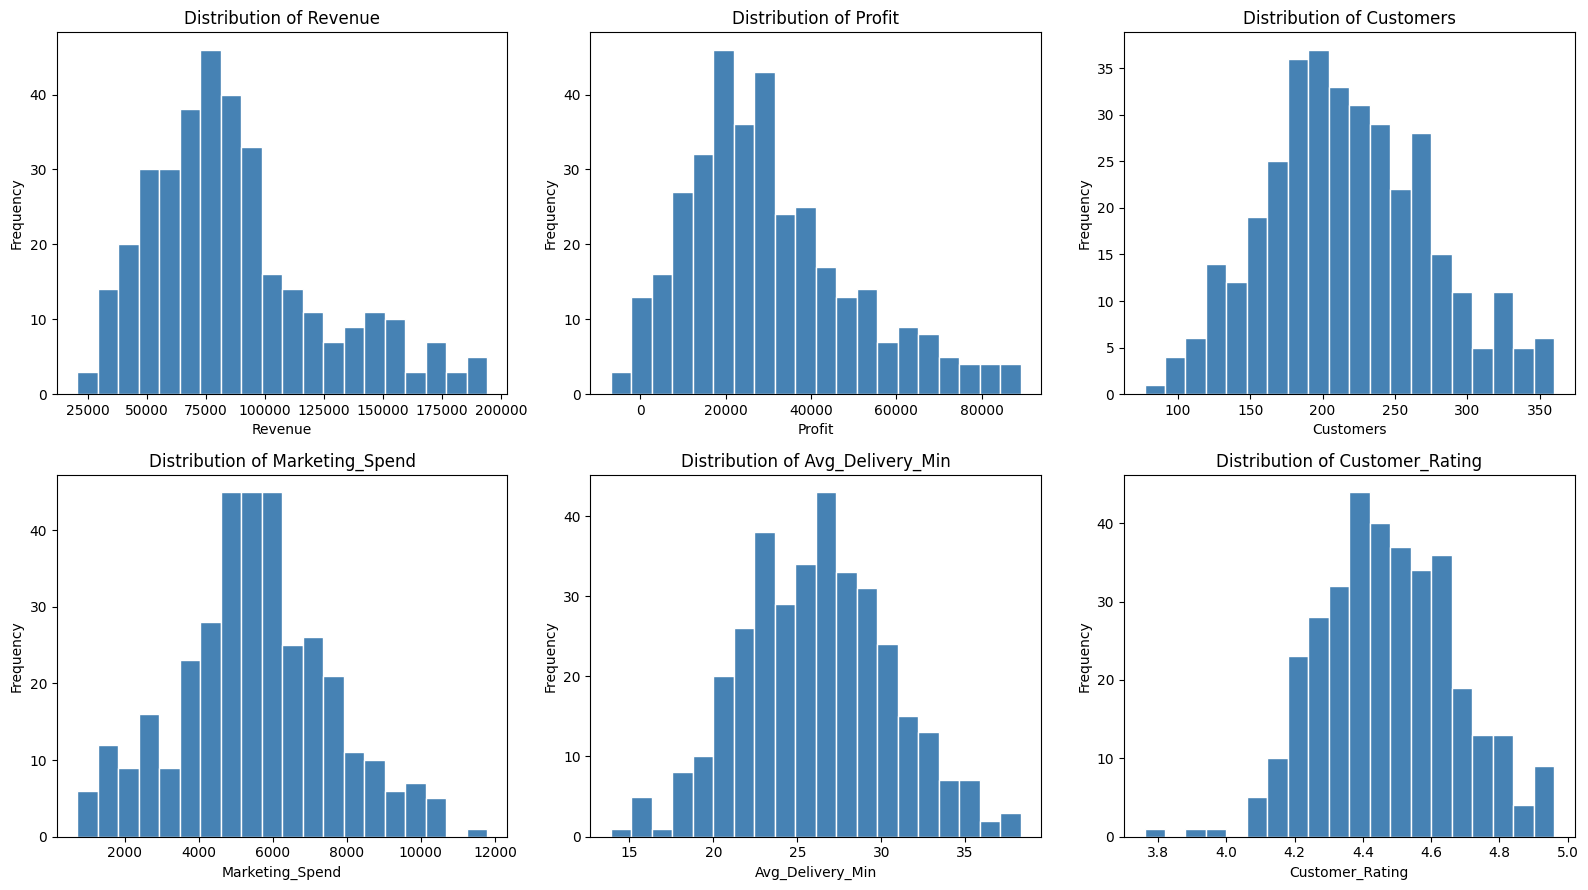

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
cols_to_plot = ['Revenue', 'Profit', 'Customers', 'Marketing_Spend', 'Avg_Delivery_Min', 'Customer_Rating']

for ax, col in zip(axes.flatten(), cols_to_plot):
    ax.hist(df[col], bins=20, color='steelblue', edgecolor='white')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

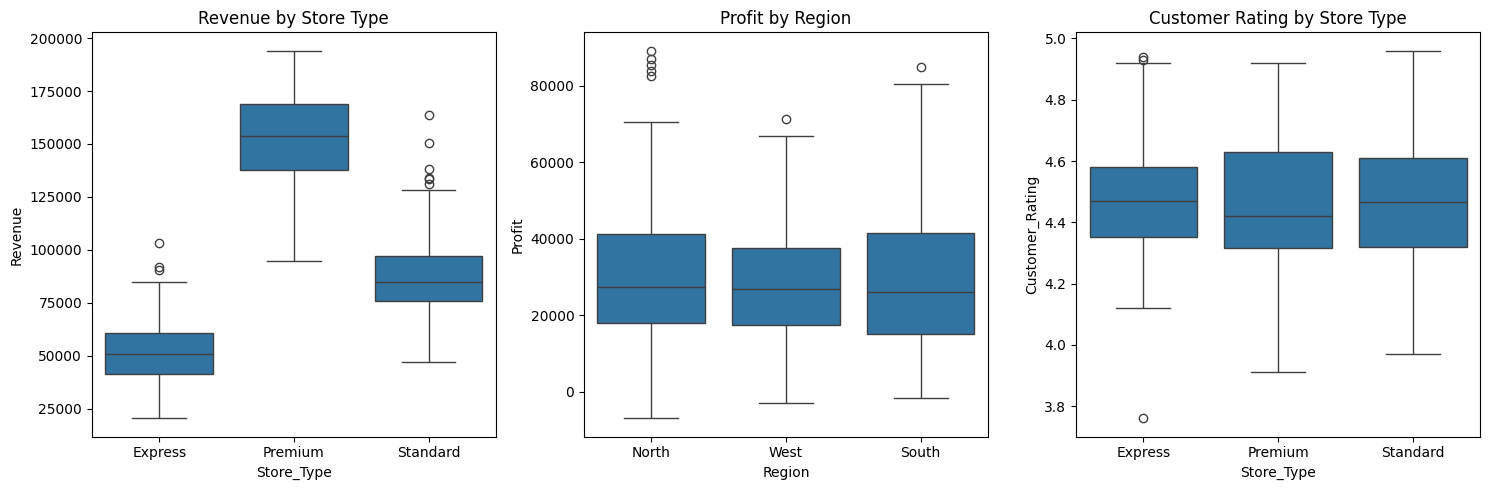

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(data=df, x='Store_Type', y='Revenue', ax=axes[0])
axes[0].set_title('Revenue by Store Type')

sns.boxplot(data=df, x='Region', y='Profit', ax=axes[1])
axes[1].set_title('Profit by Region')

sns.boxplot(data=df, x='Store_Type', y='Customer_Rating', ax=axes[2])
axes[2].set_title('Customer Rating by Store Type')

plt.tight_layout()
plt.show()

In [ ]:
# Skewness of key numerical columns
skew_summary = df[cols_to_plot].skew().sort_values(ascending=False)
print("Skewness of key metrics:")
skew_summary.round(3)

Skewness of key metrics:


Revenue             0.862
Profit              0.810
Customers           0.235
Avg_Delivery_Min    0.135
Marketing_Spend     0.104
Customer_Rating     0.067
dtype: float64

## 5. Correlation Analysis

In [ ]:
numerical_cols = ['Staff_Count', 'Marketing_Spend', 'Customers', 'Orders', 'Average_Bill',
                   'Revenue', 'Food_Cost', 'Operating_Cost', 'Profit', 'Avg_Delivery_Min',
                   'Customer_Rating', 'Temperature_C', 'Humidity_Percent']

corr_matrix = df[numerical_cols].corr()
corr_matrix.round(2)

,Staff_Count,Marketing_Spend,Customers,Orders,Average_Bill,Revenue,Food_Cost,Operating_Cost,Profit,Avg_Delivery_Min,Customer_Rating,Temperature_C,Humidity_Percent
Staff_Count,1.00,0.28,0.69,0.67,0.52,0.70,0.68,0.79,0.56,-0.18,0.08,0.08,-0.02
Marketing_Spend,0.28,1.00,0.41,0.42,0.33,0.43,0.40,0.49,0.35,0.10,-0.06,0.06,-0.05
Customers,0.69,0.41,1.00,0.98,0.53,0.88,0.84,0.86,0.84,0.18,-0.05,0.00,-0.10
Orders,0.67,0.42,0.98,1.00,0.52,0.86,0.83,0.84,0.82,0.19,-0.05,0.02,-0.09
Average_Bill,0.52,0.33,0.53,0.52,1.00,0.84,0.84,0.80,0.83,-0.03,0.04,-0.05,-0.04
Revenue,0.70,0.43,0.88,0.86,0.84,1.00,0.98,0.96,0.97,0.08,0.01,-0.03,-0.09
Food_Cost,0.68,0.40,0.84,0.83,0.84,0.98,1.00,0.97,0.92,0.08,0.00,-0.03,-0.08
Operating_Cost,0.79,0.49,0.86,0.84,0.80,0.96,0.97,1.00,0.86,0.02,0.02,0.01,-0.07
Profit,0.56,0.35,0.84,0.82,0.83,0.97,0.92,0.86,1.00,0.13,-0.01,-0.06,-0.11
Avg_Delivery_Min,-0.18,0.10,0.18,0.19,-0.03,0.08,0.08,0.02,0.13,1.00,-0.44,0.00,-0.11


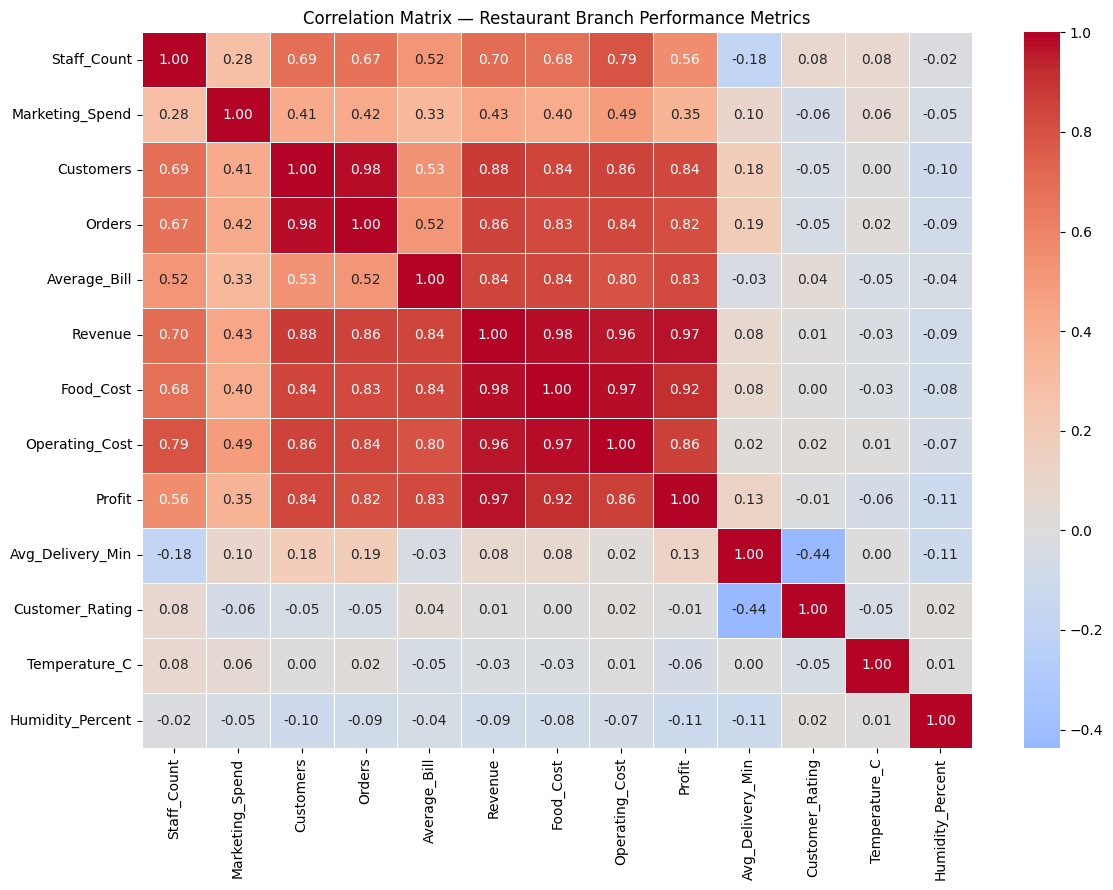

In [ ]:
plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Matrix — Restaurant Branch Performance Metrics')
plt.tight_layout()
plt.show()

In [ ]:
# Strongest correlations with Revenue and Profit
print("Correlation with Revenue:")
print(corr_matrix['Revenue'].sort_values(ascending=False))
print("\nCorrelation with Profit:")
print(corr_matrix['Profit'].sort_values(ascending=False))

Correlation with Revenue:
Revenue             1.000000
Food_Cost           0.978581
Profit              0.966831
Operating_Cost      0.962914
Customers           0.876361
Orders              0.857756
Average_Bill        0.843033
Staff_Count         0.695114
Marketing_Spend     0.431136
Avg_Delivery_Min    0.078713
Customer_Rating     0.007942
Temperature_C      -0.026119
Humidity_Percent   -0.091142
Name: Revenue, dtype: float64

Correlation with Profit:
Profit              1.000000
Revenue             0.966831
Food_Cost           0.917517
Operating_Cost      0.862061
Customers           0.835993
Average_Bill        0.828444
Orders              0.815261
Staff_Count         0.559281
Marketing_Spend     0.350265
Avg_Delivery_Min    0.128512
Customer_Rating    -0.005314
Temperature_C      -0.062630
Humidity_Percent   -0.107130
Name: Profit, dtype: float64


In [ ]:
# Does marketing spend correlate with customer count and rating?
print(f"Marketing_Spend vs Customers: {df['Marketing_Spend'].corr(df['Customers']):.3f}")
print(f"Marketing_Spend vs Customer_Rating: {df['Marketing_Spend'].corr(df['Customer_Rating']):.3f}")
print(f"Avg_Delivery_Min vs Customer_Rating: {df['Avg_Delivery_Min'].corr(df['Customer_Rating']):.3f}")
print(f"Staff_Count vs Avg_Delivery_Min: {df['Staff_Count'].corr(df['Avg_Delivery_Min']):.3f}")

Marketing_Spend vs Customers: 0.405
Marketing_Spend vs Customer_Rating: -0.062
Avg_Delivery_Min vs Customer_Rating: -0.437
Staff_Count vs Avg_Delivery_Min: -0.182


## 6. Impact of Weather and Promotions

In [ ]:
weather_impact = df.groupby('Weather').agg(
    Avg_Customers=('Customers', 'mean'),
    Avg_Revenue=('Revenue', 'mean'),
    Avg_Delivery_Min=('Avg_Delivery_Min', 'mean')
).sort_values('Avg_Revenue', ascending=False)

weather_impact.round(2)

,Avg_Customers,Avg_Revenue,Avg_Delivery_Min
Weather,,,
Rain,226.85,92974.88,25.95
Hot,213.03,87830.13,27.23
Cloudy,216.10,87724.00,26.24
Clear,216.24,84720.81,25.89


In [ ]:
promotion_impact = df.groupby('Promotion').agg(
    Avg_Customers=('Customers', 'mean'),
    Avg_Revenue=('Revenue', 'mean'),
    Avg_Profit=('Profit', 'mean'),
    Avg_Rating=('Customer_Rating', 'mean')
).sort_values('Avg_Revenue', ascending=False)

promotion_impact.round(2)

,Avg_Customers,Avg_Revenue,Avg_Profit,Avg_Rating
Promotion,,,,
Loyalty Offer,226.97,91937.89,32346.09,4.44
Weekend Offer,224.54,88808.72,31730.63,4.45
Combo Deal,218.64,86269.73,29779.94,4.45
No Promotion,212.37,85301.20,29353.92,4.49


## 7. Top and Bottom Performing Branches

In [ ]:
top_branches = branch_summary.sort_values('Avg_Profit', ascending=False).head(3)
bottom_branches = branch_summary.sort_values('Avg_Profit', ascending=True).head(3)

print("Top 3 branches by average profit:")
print(top_branches[['Avg_Profit', 'Avg_Revenue', 'Avg_Rating']])
print("\nBottom 3 branches by average profit:")
print(bottom_branches[['Avg_Profit', 'Avg_Revenue', 'Avg_Rating']])

Top 3 branches by average profit:
             Avg_Profit   Avg_Revenue  Avg_Rating
Branch                                           
Bengaluru  31890.914783  90732.118696    4.465652
Hyderabad  31402.976977  88804.899535    4.469535
Delhi      31385.295313  87573.869375    4.485625

Bottom 3 branches by average profit:
            Avg_Profit   Avg_Revenue  Avg_Rating
Branch                                          
Mumbai    26580.988409  80779.248864    4.442500
Kochi     28902.036250  85574.617917    4.419792
Srinagar  30302.915769  86746.472885    4.480192


## 8. Key Observations

1. **Revenue and profit are strongly correlated with customer count and order volume**, confirming that footfall is the primary driver of financial performance across branches.
2. **Marketing spend shows a positive but moderate correlation with customer count**, suggesting marketing helps drive footfall but isn't the sole factor — other elements like location and store type likely play a role too.
3. **Premium store types tend to generate higher average revenue and profit** than Standard or Express formats, though they may also carry higher operating costs.
4. **Delivery time shows a negative relationship with customer rating** — branches with longer average delivery times tend to receive lower customer satisfaction scores.
5. **Performance varies meaningfully by region**, with some regions consistently outperforming others in both revenue and profit margins, pointing to regional demand or cost differences.
6. **Promotions appear to boost average revenue and customer counts** compared to days with no promotion running, suggesting promotional campaigns are effective at driving business.
7. **Weather conditions influence customer footfall** — clear weather days tend to see higher average customers and revenue compared to rainy or hot days.
8. **Profit margins differ across branches even when revenue is similar**, indicating that cost control (food cost, operating cost, staffing) is as important as revenue generation for overall profitability.